# Phase 5 — Transfer Learning: Standing on Someone Else's Shoulders

Phase 4's CNN learned from 60,000 MNIST images. Your actual project will not have 60,000
labelled images. It'll have a folder with a few hundred photos in it.

Train a network from scratch on 400 images and it fails — you'll see it fail in this notebook,
scoring 52% on a two-way choice, which is a coin flip. There simply isn't enough data to learn
what edges, textures and shapes are from first principles.

**Transfer learning is the way out, and it's how nearly all real image work actually gets
done.**

### The idea

Imagine hiring someone to sort photos into "cat" and "dog".

**Option A:** hire a newborn. Teach them what light is, what edges are, what fur looks like,
what an animal is — and then, finally, cats versus dogs. From 400 photos. It's hopeless.

**Option B:** hire an adult who has been looking at the world for thirty years. They already
know what fur and ears and eyes are. You only have to teach them *one* thing: which of these
animals you call a cat and which a dog. Four hundred photos is plenty for that.

Transfer learning is Option B. Someone at Microsoft already trained ResNet18 on ImageNet — 1.2
million photographs across 1,000 categories, on hardware you don't have, for a long time. Those
weights are free to download.

Its early layers learned edges. Its middle layers learned textures and shapes. Its later layers
learned parts of things — eyes, wheels, fur. **None of that is specific to the 1,000 categories
it was trained on.** It's general-purpose seeing, and it works just as well on your photos.

### Backbone and head

Recall the two-part split from Phase 4:

- **The backbone** — all the conv layers. This is the "eyes": it turns pixels into "what
  patterns are present". This is the expensive, general part, and this is what you keep.
- **The head** — the final `Linear` layer that makes the decision. ResNet18's head answers a
  1,000-way ImageNet question. Useless to you. **Throw it away and bolt on your own.**

### Two ways to do it

**Feature extraction** — freeze the backbone so it can't change, and train only your new head.
You're saying: *"your eyes are fine, just learn my labels."* Fast, and it works with very
little data.

**Fine-tuning** — after the head is trained, unfreeze the backbone and let everything adjust
slightly. You're saying: *"now adapt your eyes a bit to my specific photos."* Needs more data
and more care, but goes further.

We'll do both, measure both, and compare against training from scratch.

### The vocabulary

| Term | What it actually means |
|---|---|
| pretrained weights | Numbers someone else already learned on a huge dataset |
| backbone | The conv layers — the general-purpose "eyes" |
| head | The final layer that makes your specific decision |
| freezing | `requires_grad = False` — "don't change this, it already works" |
| feature extraction | Freeze the backbone, train only a new head |
| fine-tuning | Unfreeze the backbone too, and nudge it gently |
| differential learning rates | Big steps for the new head, tiny steps for the expert backbone |

## What this notebook covers
```
load a pretrained ResNet18 -> build a deliberately tiny cat/dog dataset
    -> baseline: train a small CNN from scratch on it (and watch it fail)
    -> feature extraction: freeze ResNet18, train a new head
    -> fine-tuning: unfreeze, with differential learning rates
    -> compare all three on accuracy AND trainable parameters
```

## Section 1 — Loading a Pretrained Model

`torchvision.models` has dozens of architectures ready to download with their trained weights.
We're using **ResNet18** — 18 layers, about 11.7 million parameters, small and fast enough to
fine-tune on a laptop while still being genuinely good.

`ResNet18_Weights.DEFAULT` grabs the best available weight set. It scores 69.8% on ImageNet's
1,000-way classification — which sounds unimpressive until you remember that's picking the
right answer out of a thousand, where random guessing is 0.1%.

### The step everyone gets wrong: preprocessing

Here's the trap that silently ruins transfer learning.

ResNet18 learned its weights on images prepared a *specific* way — resized to 256 pixels,
cropped to 224, and normalised using ImageNet's particular mean and standard deviation per
colour channel.

**If you feed it images prepared differently, its weights don't apply properly.** The model
still runs, still outputs predictions, still trains — it just performs far worse than it should,
and nothing tells you why.

`weights.transforms()` hands you the exact pipeline those weights were trained with. Use it and
you cannot get this wrong. The alternative — copying `mean=[0.485, 0.456, 0.406]` from a blog
post and hoping — is how people lose an afternoon.

**Rule: whenever you load pretrained weights, get the preprocessing from the weights
themselves.**

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.models import resnet18, ResNet18_Weights

torch.manual_seed(42)

device = (
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using device: {device}")

# DEFAULT gets the best available weight set for this architecture.
# ResNet18: 18 layers, ~11.7M parameters -- small enough to fine-tune on a laptop,
# good enough to be genuinely useful.
weights = ResNet18_Weights.DEFAULT   # trained on ImageNet-1k by someone else, for free
resnet = resnet18(weights=weights)

top1 = weights.meta["_metrics"]["ImageNet-1K"]["acc@1"]
print(f"Pretrained on ImageNet-1k -- top-1 accuracy there: {top1}%")
# The head we're going to throw away. It answers a 1000-way ImageNet question,
# which is no use to us -- but everything BEFORE it (the backbone) is pure gold.
print(f"\nOriginal classifier head: {resnet.fc}   <- 1000 ImageNet classes")

total_params = sum(p.numel() for p in resnet.parameters())
print(f"Total parameters: {total_params:,}")

# ── PREPROCESSING — THE STEP EVERYONE GETS WRONG ─────────────────────────────
# These weights were learned on images prepared a SPECIFIC way: resized to 256,
# cropped to 224, normalised with ImageNet's particular mean and std.
#
# Prepare your images differently and the weights don't apply properly. The model
# still runs, still trains, still predicts -- just far worse, with nothing to tell
# you why.
#
# weights.transforms() hands you the exact pipeline, so you can't get it wrong.
# Never copy the mean/std constants from a blog post by hand.
preprocess = weights.transforms()
print(f"\nRequired preprocessing:\n{preprocess}")

Using device: mps
Pretrained on ImageNet-1k -- top-1 accuracy there: 69.758%

Original classifier head: Linear(in_features=512, out_features=1000, bias=True)   <- 1000 ImageNet classes
Total parameters: 11,689,512

Required preprocessing:
ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


## Section 2 — A Deliberately Tiny Dataset

CIFAR-10 has 5,000 training images per class. That's far too many to make an honest point about
transfer learning — with that much data, training from scratch works fine.

So we're throwing almost all of it away: **200 training images per class, 100 test images per
class.** Just cats and dogs. 400 images to learn from.

That's deliberately unfair to the from-scratch model, and it's deliberately realistic. **It's
what your own projects will actually look like** — a folder of a few hundred photos you
labelled by hand. This is precisely the situation where a pretrained backbone stops being a
nice-to-have and becomes the only thing that works.

### Why the labels get remapped

CIFAR-10 numbers cats as class 3 and dogs as class 5. But `CrossEntropyLoss` requires labels
running `0, 1, 2, ...` up to the number of classes minus one. Hand it a `5` when your model
only outputs 2 scores and it errors.

So `remap_label` rewrites cat → 0 and dog → 1. **Any time you take a subset of a dataset's
classes, you have to renumber them from zero.** Easy to forget, and the error message when you
do isn't especially clear.

In [2]:
import numpy as np
from torchvision.datasets import CIFAR10
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt

CLASS_NAMES = ["cat", "dog"]
CIFAR_CAT_IDX, CIFAR_DOG_IDX = 3, 5   # CIFAR-10's own class indices for these two classes

# CIFAR numbers cats as 3 and dogs as 5, but CrossEntropyLoss needs labels running
# 0, 1, 2... up to num_classes-1. Hand it a 5 when the model outputs 2 scores and
# it errors. Any time you take a SUBSET of a dataset's classes, renumber from zero.
def remap_label(y):
    return 0 if y == CIFAR_CAT_IDX else 1   # cat -> 0, dog -> 1

# CIFAR-10'''s original pickle files predate current NumPy and trigger a harmless
# dtype-pickling deprecation warning on load -- suppressed, it'''s not about our code.
import warnings
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    train_full = CIFAR10(root="data", train=True, download=True,
                          transform=preprocess, target_transform=remap_label)
    test_full = CIFAR10(root="data", train=False, download=True,
                         transform=preprocess, target_transform=remap_label)

def class_subset(dataset, n_per_class, seed=42):
    """Indices for exactly n_per_class of each cat/dog example, shuffled."""
    rng = np.random.default_rng(seed)
    targets = np.array(dataset.targets)
    indices = []
    for cifar_idx in (CIFAR_CAT_IDX, CIFAR_DOG_IDX):
        class_indices = np.where(targets == cifar_idx)[0]
        indices.extend(rng.choice(class_indices, size=n_per_class, replace=False))
    rng.shuffle(indices)
    return indices

# Deliberately tiny: 200 per class to train on, 100 per class to test.
# CIFAR offers 5,000 per class -- we're throwing 96% of it away on purpose, because
# 400 images is what YOUR project will realistically have, and it's exactly the
# regime where a pretrained backbone stops being optional.
train_indices = class_subset(train_full, n_per_class=200)
test_indices = class_subset(test_full, n_per_class=100)

train_data = Subset(train_full, train_indices)
test_data = Subset(test_full, test_indices)

print(f"Train samples: {len(train_data)}  ({len(train_data) // 2} per class)")
print(f"Test samples : {len(test_data)}  ({len(test_data) // 2} per class)")

train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

Train samples: 400  (200 per class)
Test samples : 200  (100 per class)


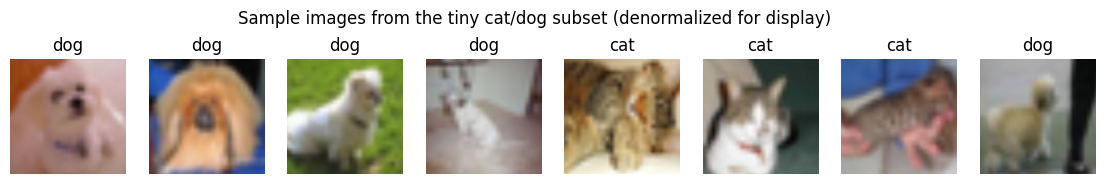

In [3]:
# ── LOOKING AT NORMALISED IMAGES ─────────────────────────────────────────────
# The preprocessing normalised these for the model's benefit, which pushes pixel
# values outside the 0-1 range matplotlib expects. Displaying them raw gives you
# psychedelic noise.
#
# Undoing it is just the reverse arithmetic: x * std + mean.
IMAGENET_MEAN = torch.tensor(preprocess.mean).view(3, 1, 1)
IMAGENET_STD = torch.tensor(preprocess.std).view(3, 1, 1)

def denormalize(img_tensor):
    img = img_tensor * IMAGENET_STD + IMAGENET_MEAN
    return img.clamp(0, 1).permute(1, 2, 0).numpy()   # (C,H,W) -> (H,W,C) for imshow

fig, axes = plt.subplots(1, 8, figsize=(14, 2.2))
for i, ax in enumerate(axes):
    image, label = train_data[i]
    ax.imshow(denormalize(image))
    ax.set_title(CLASS_NAMES[label])
    ax.axis("off")
plt.suptitle("Sample images from the tiny cat/dog subset (denormalized for display)")
plt.show()

## Section 3 — The Baseline: Training From Scratch

Before claiming transfer learning helps, we need something to compare against. So here's a
small CNN in the Phase 4 style, trained on nothing but our 400 images.

### One new piece: `AdaptiveAvgPool2d(1)`

Phase 4 hardcoded `16 * 7 * 7` in the classifier, which meant the model only worked for exactly
28×28 inputs. Change the image size and it breaks.

`nn.AdaptiveAvgPool2d(1)` fixes that. Instead of you calculating what spatial size is left, it
collapses **whatever** is there down to 1×1 by averaging. Feed it 224×224 or 28×28 or anything
else — you always get `(batch, channels, 1, 1)` out, so the `Linear` head after it always
works.

Real architectures use this everywhere, and it's why ResNet accepts a range of input sizes.
Worth adopting as a default habit — it removes a whole category of shape bugs.

### What to expect

Watch the loss. It barely moves. **The final accuracy is about 52%** — on a two-way choice,
where flipping a coin gets 50%.

The model learned essentially nothing, and that isn't a bug or a bad hyperparameter. Four
hundred images is simply not enough to learn vision from scratch. This is the honest baseline
that makes the next two sections meaningful.

In [4]:
class MiniCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            # Phase 4 hardcoded 16*7*7, so that model only worked at 28x28.
            # AdaptiveAvgPool2d(1) averages WHATEVER spatial size is left down to
            # 1x1, so the head below works for any input resolution. Worth adopting
            # as a habit -- it removes a whole category of shape bugs.
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)   # (batch, 64, 1, 1) -> (batch, 64)
        return self.classifier(x)


def train_model(model, loader, optimizer, loss_fn, epochs, label):
    model.train()
    history = []
    for epoch in range(epochs):
        total_loss = 0.0
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = loss_fn(outputs, labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_loss = total_loss / len(loader)
        history.append(avg_loss)
        print(f"[{label}] Epoch {epoch + 1}/{epochs} | Avg Loss: {avg_loss:.4f}")
    return history


def evaluate(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            predictions = model(images).argmax(dim=1)
            correct += (predictions == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total


loss_fn = nn.CrossEntropyLoss()

# THE BASELINE: no pretrained knowledge at all. Everything learned from our 400
# images. Watch the loss barely move -- 400 images is nowhere near enough to learn
# vision from first principles, and the result lands on a coin flip.
baseline = MiniCNN().to(device)
baseline_optimizer = optim.Adam(baseline.parameters(), lr=0.001)

baseline_history = train_model(baseline, train_loader, baseline_optimizer, loss_fn,
                                epochs=5, label="baseline")
baseline_acc = evaluate(baseline, test_loader)
baseline_trainable = sum(p.numel() for p in baseline.parameters() if p.requires_grad)
print(f"\nBaseline (from scratch) test accuracy: {baseline_acc:.2f}%")

[baseline] Epoch 1/5 | Avg Loss: 0.6980


[baseline] Epoch 2/5 | Avg Loss: 0.6933


[baseline] Epoch 3/5 | Avg Loss: 0.6898


[baseline] Epoch 4/5 | Avg Loss: 0.6879


[baseline] Epoch 5/5 | Avg Loss: 0.6890

Baseline (from scratch) test accuracy: 52.00%


## Section 4 — Feature Extraction: Freeze the Eyes, Train the Decision

Now the interesting part. Three steps:

**1. Freeze everything.**
```python
for param in feature_extractor.parameters():
    param.requires_grad = False
```
This is Phase 2's `requires_grad` switch used in anger. `False` means "don't compute gradients
for this, and don't let the optimizer touch it". The backbone becomes read-only — it still
*looks* at images exactly as well as before, it just can't change.

**2. Replace the head.**
```python
feature_extractor.fc = nn.Linear(feature_extractor.fc.in_features, 2)
```
Out goes the 1,000-way ImageNet layer, in comes a fresh 2-way one. Note `fc.in_features` — we
ask the old layer how many inputs it took (512) rather than hardcoding it, so this same line
works for any architecture.

A brand-new layer defaults to `requires_grad=True`, so **it is now the only trainable thing in
the entire network.**

**3. Give the optimizer only what's trainable.**
```python
optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.001)
```
The `filter` keeps only the unfrozen parameters. Skipping it isn't fatal — frozen parameters
have no gradients to apply — but it's wasteful and it makes your intent explicit.

### The number to look at

**1,026 trainable parameters.** That's 512 weights plus 2 biases, out of 11.7 million. We're
training **0.009%** of the network.

And it reaches **73%**, versus the from-scratch model's 52%.

Sit with that for a second. A thousand parameters, trained on 400 images, beating a
purpose-built CNN with twenty times more trainable weights — by twenty-one points. All the real
work was done by a backbone that never changed at all.

In [5]:
# A fresh copy of the pretrained ResNet18 -- 11.7 million numbers that already
# know how to see, courtesy of 1.2 million ImageNet photos.
feature_extractor = resnet18(weights=weights)

# STEP 1: FREEZE EVERYTHING.
# This is Phase 2's requires_grad switch used in anger. False means 'compute no
# gradients for this, and don't let the optimizer touch it'. The backbone still
# sees just as well -- it simply can't change.
for param in feature_extractor.parameters():
    param.requires_grad = False

# STEP 2: REPLACE THE HEAD.
# Out goes the 1000-way ImageNet layer, in comes a fresh 2-way one.
# We ask the old layer how many inputs it took (fc.in_features = 512) instead of
# hardcoding it, so this same line works for any architecture.
#
# A brand-new layer defaults to requires_grad=True, so it is now the ONLY
# trainable thing in the whole network.
feature_extractor.fc = nn.Linear(feature_extractor.fc.in_features, len(CLASS_NAMES))
feature_extractor = feature_extractor.to(device)

fe_trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
fe_total = sum(p.numel() for p in feature_extractor.parameters())
print(f"Trainable parameters: {fe_trainable:,} / {fe_total:,} total ({100 * fe_trainable / fe_total:.2f}%)")

# STEP 3: hand the optimizer only what's actually trainable.
# filter() keeps just the unfrozen parameters -- here, only the new fc layer.
# 1,026 numbers (512 weights + 2 biases) out of 11.7 million. We're training
# 0.009% of this network... and it still beats the from-scratch model by 21 points.
fe_optimizer = optim.Adam(filter(lambda p: p.requires_grad, feature_extractor.parameters()), lr=0.001)

fe_history = train_model(feature_extractor, train_loader, fe_optimizer, loss_fn,
                          epochs=5, label="feature-extraction")
fe_acc = evaluate(feature_extractor, test_loader)
print(f"\nFeature-extraction test accuracy: {fe_acc:.2f}%")

Trainable parameters: 1,026 / 11,177,538 total (0.01%)


[feature-extraction] Epoch 1/5 | Avg Loss: 0.7242


[feature-extraction] Epoch 2/5 | Avg Loss: 0.6173


[feature-extraction] Epoch 3/5 | Avg Loss: 0.5611


[feature-extraction] Epoch 4/5 | Avg Loss: 0.5219


[feature-extraction] Epoch 5/5 | Avg Loss: 0.4794



Feature-extraction test accuracy: 73.00%


## Section 5 — Fine-Tuning: Now Let the Eyes Adjust

Feature extraction kept the backbone completely fixed. But ImageNet photos are large and
detailed, and ours are blurry 32×32 CIFAR upscales. The backbone is good but not *ideally*
suited. Let's let it adapt.

We unfreeze everything and keep training. But **not at the same speed for everything** — and
this is the part worth understanding.

### Why two different learning rates

Think about who knows what:

- **The backbone** spent enormous effort learning to see, on a million-plus images. Its weights
  are *nearly right*. Take big steps here and you'd destroy that knowledge in a few batches —
  it even has a name, *catastrophic forgetting*. It needs a tiny learning rate: `1e-5`.
- **The head** was created from random noise a few minutes ago and only trained on 400 images.
  It has much further to go and nothing precious to lose. It keeps the larger rate: `1e-3`.

That's a **100× difference**, and it's expressed with **parameter groups** — you hand the
optimizer a list of dictionaries, each with its own settings:

```python
optim.Adam([
    {"params": model.fc.parameters(), "lr": 1e-3},   # the new head: big steps
    {"params": backbone_params,       "lr": 1e-5},   # the expert: gentle nudges
])
```

### Order matters

Notice we fine-tune **after** the head is already trained. That's deliberate.

If you unfroze everything while the head was still random, the huge nonsense gradients from that
untrained layer would flow straight back into the carefully-trained backbone and wreck it. Train
the head first, *then* unfreeze. **Head first, then fine-tune** — that's the standard recipe.

Three epochs takes us from 73% to **81.5%**.

In [6]:
# Unfreeze everything so the backbone can adapt to our particular blurry images.
#
# Note the ORDER: we're doing this AFTER the head is already trained. Unfreezing
# while the head was still random would send its huge nonsense gradients straight
# back into the carefully-trained backbone and wreck it.
# Head first, then fine-tune.
for param in feature_extractor.parameters():
    param.requires_grad = True

ft_trainable = sum(p.numel() for p in feature_extractor.parameters() if p.requires_grad)
print(f"Trainable parameters: {ft_trainable:,}  (the entire model, now unfrozen)")

# TWO LEARNING RATES, because the two halves know very different amounts:
#
#   the backbone  -> learned to see from 1.2M images. Nearly right already.
#                    Big steps here would destroy that knowledge (it has a name:
#                    'catastrophic forgetting'). Tiny rate: 1e-5.
#   the head      -> was random noise a few minutes ago, trained on 400 images.
#                    Long way to go, nothing precious to lose. Keeps 1e-3.
#
# A 100x difference, expressed with 'parameter groups' -- a list of dicts, each
# with its own settings.
ft_optimizer = optim.Adam([
    {"params": feature_extractor.fc.parameters(), "lr": 1e-3},
    {"params": (p for n, p in feature_extractor.named_parameters() if not n.startswith("fc")), "lr": 1e-5},
])

ft_history = train_model(feature_extractor, train_loader, ft_optimizer, loss_fn,
                          epochs=3, label="fine-tune")
ft_acc = evaluate(feature_extractor, test_loader)
print(f"\nFine-tuned test accuracy: {ft_acc:.2f}%")

Trainable parameters: 11,177,538  (the entire model, now unfrozen)


[fine-tune] Epoch 1/3 | Avg Loss: 0.4752


[fine-tune] Epoch 2/3 | Avg Loss: 0.3889


[fine-tune] Epoch 3/3 | Avg Loss: 0.2752



Fine-tuned test accuracy: 81.50%


## Section 6 — The Three-Way Comparison

Same 400 training images for all three. The only difference is how much pretrained knowledge
each one started with.

| Approach | Trainable params | Accuracy |
|---|---|---|
| MiniCNN, from scratch | 23,714 | **52.00%** |
| ResNet18, feature extraction | 1,026 | **73.00%** |
| ResNet18, fine-tuned | 11,177,538 | **81.50%** |

Read the first two rows against each other, because that's the whole lesson of this notebook:

> **1,026 trainable parameters beat 23,714 by twenty-one points.**

The from-scratch model had *more* trainable weights, a sensible architecture, and identical
data — and it landed on a coin flip. The feature extractor trained a single small layer and
crushed it.

**The difference wasn't the model or the training. It was the 11.7 million frozen numbers that
came pretrained.**

That's the thing to take away: with a small dataset, *where you start* matters far more than
what you build or how long you train. Fine-tuning then adds another 8.5 points by letting those
frozen numbers adjust slightly to our particular blurry images.

### When to use which

| Your situation | Do this |
|---|---|
| A few hundred images, similar to everyday photos | **Feature extraction.** Fast, and little risk of overfitting. |
| A few thousand images | **Fine-tune**, small backbone learning rate. |
| Very different domain (X-rays, satellites, microscopy) | Fine-tune more layers — ImageNet's later features are less relevant. |
| Genuinely huge dataset | Training from scratch becomes viable, though starting pretrained still usually converges faster. |

The honest default for most projects: **start with feature extraction.** It takes ten minutes
and tells you immediately whether the problem is easy. Only reach for fine-tuning if you need
more.

Model                         Trainable Params   Test Accuracy
MiniCNN (from scratch)                  23,714          52.00%
ResNet18 (feature extract)               1,026          73.00%
ResNet18 (fine-tuned)               11,177,538          81.50%


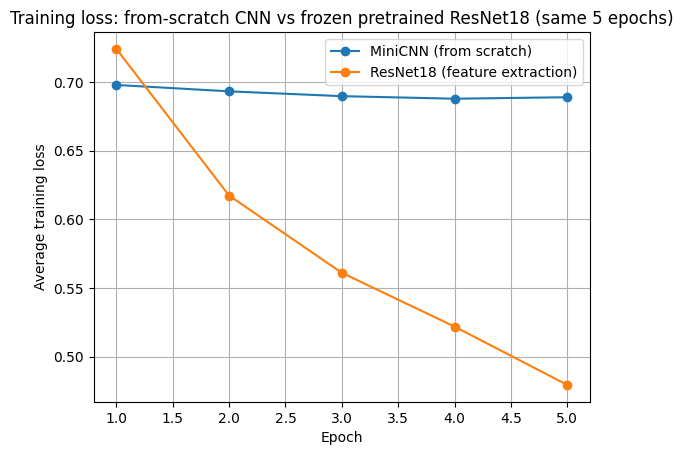

In [7]:
# Read the first two rows against each other -- that's the whole lesson:
# 1,026 trainable parameters beat 23,714 by twenty-one points. The difference
# wasn't the architecture or the training. It was the 11.7 million frozen numbers
# that arrived already knowing how to see.
print(f"{'Model':<28}{'Trainable Params':>18}{'Test Accuracy':>16}")
print(f"{'MiniCNN (from scratch)':<28}{baseline_trainable:>18,}{baseline_acc:>15.2f}%")
print(f"{'ResNet18 (feature extract)':<28}{fe_trainable:>18,}{fe_acc:>15.2f}%")
print(f"{'ResNet18 (fine-tuned)':<28}{ft_trainable:>18,}{ft_acc:>15.2f}%")

plt.plot(range(1, len(baseline_history) + 1), baseline_history, marker="o", label="MiniCNN (from scratch)")
plt.plot(range(1, len(fe_history) + 1), fe_history, marker="o", label="ResNet18 (feature extraction)")
plt.xlabel("Epoch")
plt.ylabel("Average training loss")
plt.title("Training loss: from-scratch CNN vs frozen pretrained ResNet18 (same 5 epochs)")
plt.legend()
plt.grid(True)
plt.show()

## Section 7 — Looking at the Predictions

The fine-tuned model on random test images, green for right and red for wrong.

Remember these are 32×32 CIFAR images blown up to 224×224, so they're genuinely blurry — some
are hard for a person too. At 81.5%, roughly one in five is wrong, so run it a few times and
you'll see mistakes.

Note we call `denormalize()` before displaying. The images were normalised with ImageNet's mean
and standard deviation for the model's benefit, which pushes pixel values outside the 0–1 range
matplotlib expects. Undoing it (`x * std + mean`) makes them viewable again. **If your images
ever display as psychedelic noise, this is why.**

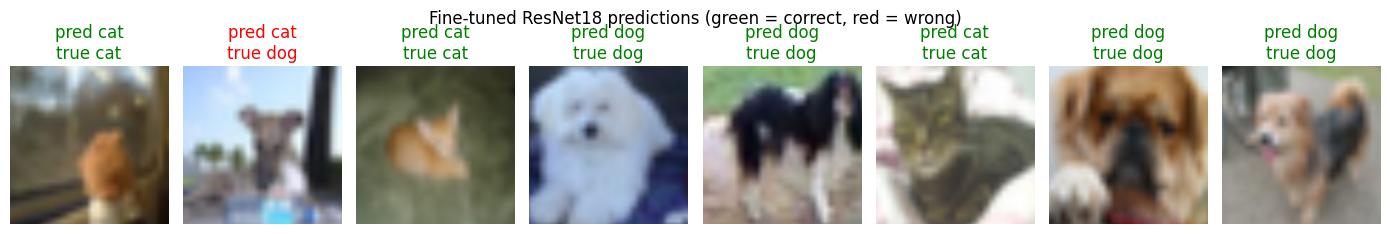

In [8]:
feature_extractor.eval()
n_show = 8
indices = torch.randint(0, len(test_data), (n_show,))

fig, axes = plt.subplots(1, n_show, figsize=(14, 2.4))
with torch.no_grad():
    for ax, idx in zip(axes, indices):
        image, true_label = test_data[idx]
        input_batch = image.unsqueeze(0).to(device)
        predicted_label = feature_extractor(input_batch).argmax(dim=1).item()

        ax.imshow(denormalize(image))   # undo the normalisation, or it's noise
        is_correct = predicted_label == true_label
        ax.set_title(f"pred {CLASS_NAMES[predicted_label]}\ntrue {CLASS_NAMES[true_label]}",
                     color="green" if is_correct else "red")
        ax.axis("off")

plt.suptitle("Fine-tuned ResNet18 predictions (green = correct, red = wrong)")
plt.tight_layout()
plt.show()

## Phase 5 Summary

### Cheat sheet
```
Loading a pretrained model:
  weights = ResNet18_Weights.DEFAULT
  model = resnet18(weights=weights)
  preprocess = weights.transforms()    <- ALWAYS get preprocessing from the weights.
                                          Wrong preprocessing = silently much worse results.

Feature extraction -- freeze the eyes, train the decision:
  for p in model.parameters(): p.requires_grad = False       # freeze everything
  model.fc = nn.Linear(model.fc.in_features, num_classes)    # new head, trainable by default
  optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-3)

Fine-tuning -- let the eyes adjust, gently:
  for p in model.parameters(): p.requires_grad = True
  optim.Adam([
      {"params": model.fc.parameters(), "lr": 1e-3},    # new head: big steps
      {"params": backbone_params,       "lr": 1e-5},    # expert: 100x gentler
  ])
  Train the head FIRST, then unfreeze -- or a random head's gradients wreck the backbone.

Handy:
  nn.AdaptiveAvgPool2d(1)   -> collapses any spatial size to 1x1, so the head works
                                for any input resolution. Removes a class of shape bugs.
  denormalize before display -> normalised images look like noise in matplotlib

Which to choose:
  few hundred images, ordinary photos -> feature extraction (fast, low overfitting risk)
  few thousand images                 -> fine-tune, small backbone lr
  very different domain (X-ray, etc.) -> fine-tune deeper
  genuinely huge dataset              -> from scratch becomes viable

The result, all three on the SAME 400 training images:
  MiniCNN from scratch          23,714 trainable  ->  52.00%   (a coin flip)
  ResNet18 feature extraction    1,026 trainable  ->  73.00%
  ResNet18 fine-tuned       11,177,538 trainable  ->  81.50%
```

### The five things worth memorising

1. **With a small dataset, where you START matters more than what you build.** 1,026 trained
   parameters beat 23,714 by 21 points.
2. **Get preprocessing from `weights.transforms()`.** Guessing it is a silent, expensive bug.
3. **Freeze with `requires_grad = False`; replace the head with your own `nn.Linear`.**
4. **Train the head first, then unfreeze.** A random head's gradients will damage a pretrained
   backbone.
5. **Fine-tune with differential learning rates** — roughly 100× smaller for the backbone.

### Test yourself before moving on

1. Cut the training set to 50 images per class. Which approach degrades most? Why?
2. Fine-tune with `lr=1e-3` on the backbone instead of `1e-5`. What happens to accuracy, and
   what's that called?
3. Swap `resnet18` for `resnet50`. More parameters — is it better on 400 images?
4. Skip `weights.transforms()` and just use `ToTensor()`. How much accuracy does that cost?

### Up next — Phase 6: Training Techniques That Matter
Data augmentation, Dropout and BatchNorm, learning-rate scheduling, early stopping — the
techniques that turn a model that *runs* into one that actually generalises.